# SARIMA | SARIMAX

In [2]:
import pandas as pd

In [4]:
df = pd.read_csv('us-airlines-monthly-aircraft-miles-flown.csv', header =0, parse_dates=[0])
df.head()

,Month,MilesMM
0,1963-01-01,6827
1,1963-02-01,6178
2,1963-03-01,7084
3,1963-04-01,8162
4,1963-05-01,8462


In [8]:
df.index= df['Month']
df.head()

,Month,MilesMM
Month,,
1963-01-01,1963-01-01,6827
1963-02-01,1963-02-01,6178
1963-03-01,1963-03-01,7084
1963-04-01,1963-04-01,8162
1963-05-01,1963-05-01,8462


In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

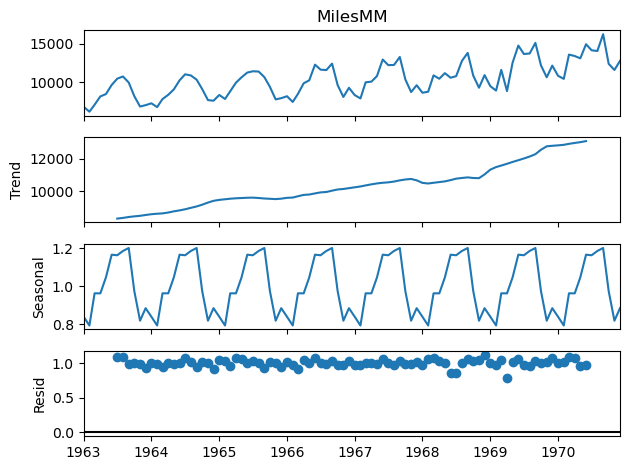

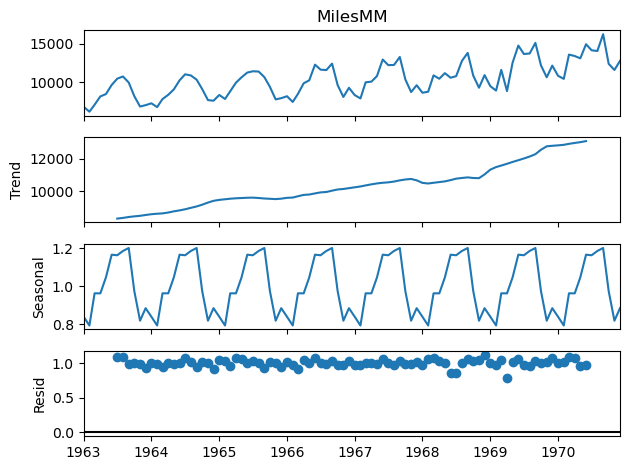

In [21]:
plot1 = seasonal_decompose(df['MilesMM'], model='multiplicative')
plot1.plot()

- monthly data and yearly seasonality

D:\New folder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\New folder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\New folder\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<Axes: xlabel='Month'>

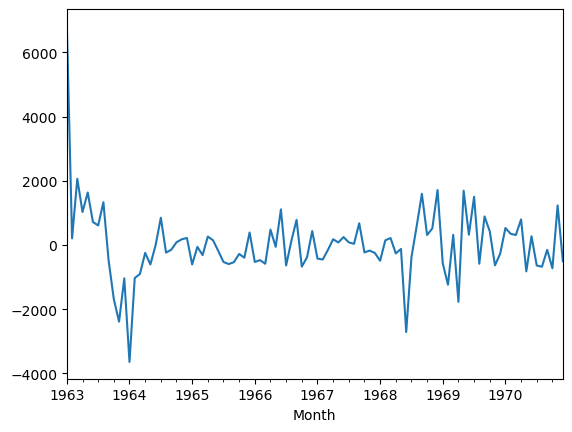

In [25]:
model = SARIMAX(df['MilesMM'], order=(5,1,2), seasonal_order=(1,1,1,12))
model_fit = model.fit()
residuals = model_fit.resid
residuals.plot()

In [27]:
output = model_fit.forecast()
output

1971-01-01    11321.694663
Freq: MS, dtype: float64

In [35]:
import matplotlib.pyplot as plt
y_hat = model_fit.predict()

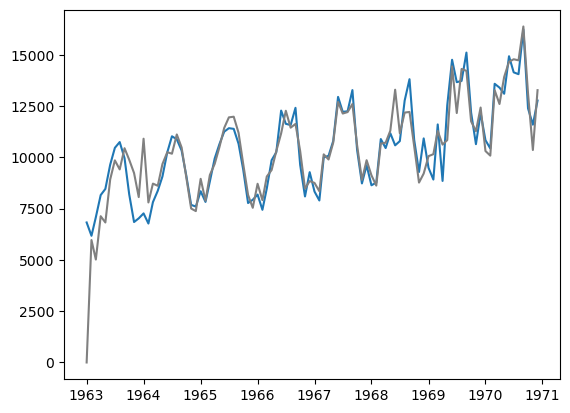

In [36]:
plt.plot(df['MilesMM'])
plt.plot(y_hat, color='grey')